In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv('Mall_Customers.csv')

print("\n--- First 5 Rows ---")
print(df.head())
print("\n--- Data Info (types, missing values) ---")
df.info()
print("\n--- Statistical Summary (for numerical columns) ---")
print(df.describe())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())


--- First 5 Rows ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

--- Data Info (types, missing values) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage:

In [24]:
from sklearn.preprocessing import StandardScaler
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("--- Scaled Data (First 5 Rows) ---")
print(X_scaled[:5])

print(f"\nScaled data shape: {X_scaled.shape}")

--- Scaled Data (First 5 Rows) ---
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]

Scaled data shape: (200, 2)


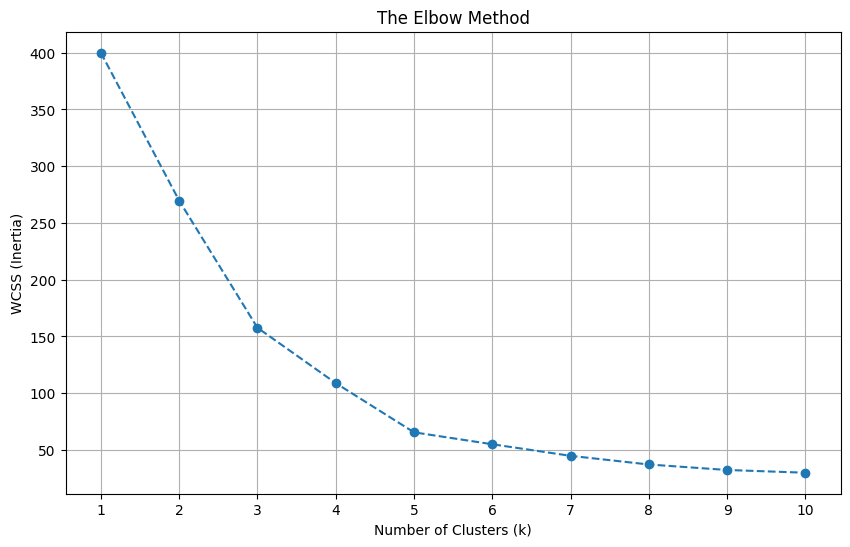

In [25]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, 
                    init='k-means++', 
                    n_init=10,  
                    max_iter=300,     
                    random_state=42)  
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) 
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [26]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, 
                init='k-means++', 
                n_init=10, 
                max_iter=300, 
                random_state=42)

cluster_labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = cluster_labels

print("--- Data with Cluster Labels (First 5 Rows) ---")
print(df.head())

cluster_centers_scaled = kmeans.cluster_centers_
cluster_centers = scaler.inverse_transform(cluster_centers_scaled)

print("\n--- Cluster Centers (Original Scale) ---")
print(pd.DataFrame(cluster_centers, columns=features))

--- Data with Cluster Labels (First 5 Rows) ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  

--- Cluster Centers (Original Scale) ---
   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043


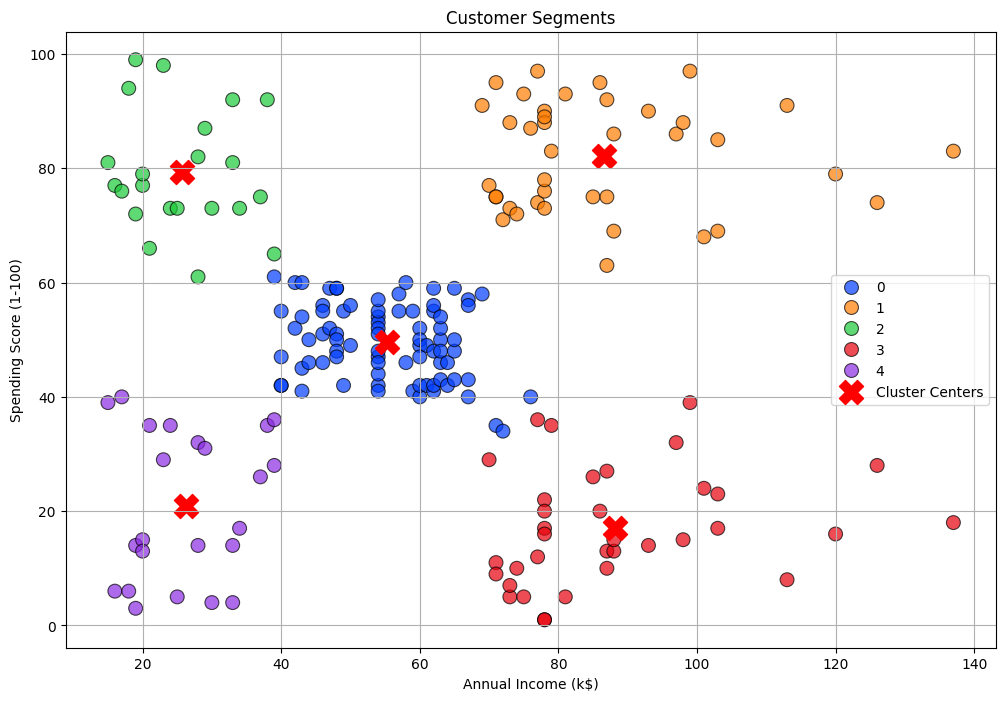

In [27]:

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=df['Annual Income (k$)'], 
    y=df['Spending Score (1-100)'], 
    hue=df['Cluster'],
    palette=sns.color_palette('bright', n_colors=optimal_k),
    s=100, 
    alpha=0.7,
    edgecolor='black'
)

plt.scatter(
    x=cluster_centers[:, 0],
    y=cluster_centers[:, 1], 
    s=300,                  
    c='red',
    marker='X',
    label='Cluster Centers'
)

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
new_customer = [[99, 80]]

new_customer_scaled = scaler.transform(new_customer)

predicted_cluster = kmeans.predict(new_customer_scaled)

print(f"\nNew customer data (scaled): {new_customer_scaled}")
print(f"Predicted cluster for new customer: {predicted_cluster[0]}")



New customer data (scaled): [[1.46723286 1.15688251]]
Predicted cluster for new customer: 1


/home/mahesh/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
